
## Part 1 - Data Warehouse Modeling: Star Schema

### 1.1 Business Process and Grain

The aim of this homework is to build a small data warehouse for the analysis of financial transactions recorded in the 2024 account statement, organizing the data in a way that makes it possible to study the transactions from different points of view.

The most important event of the analysis is the financial transaction. For this reason, the central fact table is called Fact_Transactions.

The grain of the fact table is at transaction level: each row represents one valid transaction record from the account statement. The data are not already aggregated, but further aggregations could be obtained later through analytical queries.

The main measure is unit, which represents the number of units involved in the transaction. The number of transactions is also useful, but it is not stored because it can simply be obtained by counting the rows of the fact table.

### 1.2 Fact Table and Dimensions

The model is designed as a star schema, with one fact table and four dimensions.

Fact_Transactions: transaction_key, time_key, symbol_key, geography_key, transaction_type_key, unit

Dim_Time: date, day, month, month_name, quarter, year, day_of_week

Dim_Symbol: symbol, company_name, industry, sector

Dim_Geography: country, alpha_2, alpha_3, sub_region, region

Dim_TransactionType: transaction_type

Not all source attributes were kept in the final schema. Some fields were not useful for the analytical goals of the queries, while related attributes from different source files were grouped into the same dimension.
For example, symbol, company, industry and sector were grouped in Dim_Symbol, while country and geographical classification were grouped in Dim_Geography.

### 1.3 Dimension Hierarchies

The dimensions support different levels of aggregation:

Dim_Time: day, month, quarter, year

Dim_Geography: country, sub-region, region

Dim_Symbol: symbol or company, industry, sector

Dim_TransactionType does not have a real hierarchy. It is only used to distinguish BUY, SELL and dividend-related transactions.

### 1.4 Star Schema Design

The final schema is shown in the diagram below.

![Star Schema Diagram](diagram/star_schema_homework3.png)

Fact_Transactions contains a surrogate key called transaction_key. This choice is important because the source field IDTransaction is not reliable as a unique identifier: during the ETL phase, it appears more than once for different transaction rows. A new technical key is therefore created to uniquely identify each row of the final fact table.

The fact table also contains the foreign keys time_key, symbol_key, geography_key and transaction_type_key, which connect it to the four dimensions. Each dimension has its own surrogate key, making the model more stable and independent from the original source values.

The diagram uses a simplified relational-style notation to show the logical structure of the star schema. The data types are only indicative. The actual implementation is based on pandas DataFrames and CSV files, not on physical SQL tables, while consistency is checked during the ETL process through uniqueness and missing-value checks.

The star schema diagram is also saved as a separate file in the project folder.


## Part 2 - ETL and Analytical Queries

### 2.1 ETL and Star Schema Implementation





In [68]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import os

# Create the folder for the processed files
os.makedirs("data/processed", exist_ok=True)

# File paths
account_path = "data/raw/account-statement-1-1-2024-12-31-2024.csv"
symbols_path = "data/raw/symbols.csv"
country_path = "data/raw/country.csv"

In [69]:
# Load the three source files
account_raw = pd.read_csv(account_path, sep=";")
symbols_raw = pd.read_csv(symbols_path, sep=";")
country_raw = pd.read_csv(country_path)

# Check their size
print("Account statement:", account_raw.shape)
print("Symbols:", symbols_raw.shape)
print("Country:", country_raw.shape)

Account statement: (2745, 6)
Symbols: (3194, 5)
Country: (249, 11)


In [70]:
# Check the columns of the source files
print("Account statement columns:")
print(account_raw.columns.tolist())

print("\nSymbols columns:")
print(symbols_raw.columns.tolist())

print("\nCountry columns:")
print(country_raw.columns.tolist())

Account statement columns:
['IDTransaction', 'Date', 'TransactionType', 'Symbol', 'Unit', 'Unnamed: 5']

Symbols columns:
['symbol', 'company_name', 'sector', 'industry', 'country']

Country columns:
['name', 'alpha-2', 'alpha-3', 'country-code', 'iso_3166-2', 'region', 'sub-region', 'intermediate-region', 'region-code', 'sub-region-code', 'intermediate-region-code']


In [71]:
# First rows
display(account_raw.head())
display(symbols_raw.head())
display(country_raw.head())

,IDTransaction,Date,TransactionType,Symbol,Unit,Unnamed: 5
0,2.769834e+09,11/01/2024 10:44:03,BUY,BAP,1605.0,NaN
1,2.767325e+09,24/01/2024 08:07:24,SELL,BAP,1605.0,NaN
2,2.815474e+09,10/01/2024 11:00:08,SELL,BAP,914.0,NaN
3,2.622244e+09,16/01/2024 08:14:21,BUY,ACGL,646.0,NaN
4,2.629871e+09,16/01/2024 14:34:12,SELL,ALVO,646.0,NaN


,symbol,company_name,sector,industry,country
0,TEAM,Atlassian Corporation,Technology,Software - Application,Australia
1,WDS,Woodside Energy Group Limited,Energy,Oil & Gas E&P,Australia
2,OSW,OneSpaWorld Holdings Limited,Consumer Cyclical,Leisure,Bahamas
3,ACGL,Arch Capital Group Ltd.,Financial Services,Insurance - Diversified,Bermuda
4,AGO,Assured Guaranty Ltd.,Financial Services,Insurance - Specialty,Bermuda


,name,alpha-2,alpha-3,country-code,iso_3166-2,region,sub-region,intermediate-region,region-code,sub-region-code,intermediate-region-code
0,Afghanistan,AF,AFG,4,ISO 3166-2:AF,Asia,Southern Asia,NaN,142.0,34.0,NaN
1,Åland Islands,AX,ALA,248,ISO 3166-2:AX,Europe,Northern Europe,NaN,150.0,154.0,NaN
2,Albania,AL,ALB,8,ISO 3166-2:AL,Europe,Southern Europe,NaN,150.0,39.0,NaN
3,Algeria,DZ,DZA,12,ISO 3166-2:DZ,Africa,Northern Africa,NaN,2.0,15.0,NaN
4,American Samoa,AS,ASM,16,ISO 3166-2:AS,Oceania,Polynesia,NaN,9.0,61.0,NaN


In [72]:
 # Data types
print("Account statement data types:")
display(account_raw.dtypes)

print("\nSymbols data types:")
display(symbols_raw.dtypes)

print("\nCountry data types:")
display(country_raw.dtypes)

Account statement data types:


IDTransaction      float64
Date                   str
TransactionType        str
Symbol                 str
Unit               float64
Unnamed: 5         float64
dtype: object


Symbols data types:


symbol          str
company_name    str
sector          str
industry        str
country         str
dtype: object


Country data types:


name                            str
alpha-2                         str
alpha-3                         str
country-code                  int64
iso_3166-2                      str
region                          str
sub-region                      str
intermediate-region             str
region-code                 float64
sub-region-code             float64
intermediate-region-code    float64
dtype: object

The initial inspection shows that the account statement includes an extra column called Unnamed: 5, which does not contain useful information for the model and will be removed during cleaning. The Date attribute is initially read as a string and must be converted to a datetime format. The symbols dataset contains the attributes needed for the symbol dimension, while the country dataset contains more attributes than required, so only the columns useful for the geography dimension will be kept.


#### Data Quality Checks




In [73]:
# Missing values in the source files
print("Missing values in account statement:")
display(account_raw.isna().sum())
display((account_raw.isna().mean() * 100).round(2))

print("\nMissing values in symbols:")
display(symbols_raw.isna().sum())
display((symbols_raw.isna().mean() * 100).round(2))

print("\nMissing values in country:")
display(country_raw.isna().sum())
display((country_raw.isna().mean() * 100).round(2))

Missing values in account statement:


IDTransaction       464
Date                464
TransactionType     464
Symbol              464
Unit                464
Unnamed: 5         2745
dtype: int64

IDTransaction       16.9
Date                16.9
TransactionType     16.9
Symbol              16.9
Unit                16.9
Unnamed: 5         100.0
dtype: float64


Missing values in symbols:


symbol          0
company_name    0
sector          0
industry        0
country         0
dtype: int64

symbol          0.0
company_name    0.0
sector          0.0
industry        0.0
country         0.0
dtype: float64


Missing values in country:


name                          0
alpha-2                       1
alpha-3                       0
country-code                  0
iso_3166-2                    0
region                        2
sub-region                    2
intermediate-region         144
region-code                   2
sub-region-code               2
intermediate-region-code    144
dtype: int64

name                         0.00
alpha-2                      0.40
alpha-3                      0.00
country-code                 0.00
iso_3166-2                   0.00
region                       0.80
sub-region                   0.80
intermediate-region         57.83
region-code                  0.80
sub-region-code              0.80
intermediate-region-code    57.83
dtype: float64

The missing values check shows that the account statement contains 464 rows with missing values in all the main transaction attributes. These rows do not provide usable transaction information and will be removed during the cleaning phase.

The symbols dataset does not contain missing values in the available columns. The country dataset contains a few missing values in region and sub-region, while intermediate-region has many missing values but it will not be used in the final model.


In [74]:
# Check empty rows in the account statement
main_columns = ["IDTransaction", "Date", "TransactionType", "Symbol", "Unit"]

empty_rows = account_raw[main_columns].isna().all(axis=1).sum()
valid_rows = len(account_raw) - empty_rows

print("Empty rows:", empty_rows)
print("Valid rows before cleaning:", valid_rows)

Empty rows: 464
Valid rows before cleaning: 2281


In [75]:
# Remove empty rows and unused column
account_clean = account_raw.dropna(subset=main_columns, how="all").copy()

account_clean = account_clean.drop(columns=["Unnamed: 5"])

print("Shape after cleaning:", account_clean.shape)
display(account_clean.head())

Shape after cleaning: (2281, 5)


,IDTransaction,Date,TransactionType,Symbol,Unit
0,2.769834e+09,11/01/2024 10:44:03,BUY,BAP,1605.0
1,2.767325e+09,24/01/2024 08:07:24,SELL,BAP,1605.0
2,2.815474e+09,10/01/2024 11:00:08,SELL,BAP,914.0
3,2.622244e+09,16/01/2024 08:14:21,BUY,ACGL,646.0
4,2.629871e+09,16/01/2024 14:34:12,SELL,ALVO,646.0


In [76]:
# Convert Date to datetime
account_clean["Date"] = pd.to_datetime(account_clean["Date"], dayfirst=True, errors="coerce")

# Check dates
print("Invalid dates:", account_clean["Date"].isna().sum())
print("First date:", account_clean["Date"].min())
print("Last date:", account_clean["Date"].max())

Invalid dates: 0
First date: 2024-01-02 14:33:01
Last date: 2024-12-30 15:00:09


In [77]:
# Check transaction types
transaction_type_counts = account_clean["TransactionType"].value_counts()

display(transaction_type_counts)

TransactionType
SELL        1089
BUY         1082
DIVIDENT     110
Name: count, dtype: int64

In [78]:
# Check Unit values
print("Missing Unit values:", account_clean["Unit"].isna().sum())
print("Minimum Unit:", account_clean["Unit"].min())
print("Maximum Unit:", account_clean["Unit"].max())

# Convert Unit to integer
account_clean["Unit"] = account_clean["Unit"].astype(int)

print("Unit type:", account_clean["Unit"].dtype)

Missing Unit values: 0
Minimum Unit: 7.0
Maximum Unit: 1605.0
Unit type: int64


In [79]:
# Check if IDTransaction is unique
total_rows = len(account_clean)
unique_ids = account_clean["IDTransaction"].nunique()
duplicated_ids = account_clean["IDTransaction"].duplicated().sum()

print("Total rows:", total_rows)
print("Unique IDTransaction:", unique_ids)
print("Duplicated IDTransaction rows:", duplicated_ids)

Total rows: 2281
Unique IDTransaction: 1136
Duplicated IDTransaction rows: 1145


IDTransaction is not unique, so I did not use it as the primary key of the fact table. Instead, I created a new surrogate key called transaction_key.

In [80]:
# Select columns for Dim_Symbol
symbols_clean = symbols_raw[["symbol", "company_name", "sector", "industry", "country"]].copy()

# Check symbols
total_symbols = len(symbols_clean)
unique_symbols = symbols_clean["symbol"].nunique()
duplicated_symbols = symbols_clean["symbol"].duplicated().sum()

print("Total symbol rows:", total_symbols)
print("Unique symbols:", unique_symbols)
print("Duplicated symbols:", duplicated_symbols)

Total symbol rows: 3194
Unique symbols: 3194
Duplicated symbols: 0


In [81]:
# Select columns for Dim_Geography
country_clean = country_raw[["name", "alpha-2", "alpha-3", "region", "sub-region"]].copy()

# Rename columns
country_clean = country_clean.rename(columns={
    "name": "country",
    "alpha-2": "alpha_2",
    "alpha-3": "alpha_3",
    "sub-region": "sub_region"
})

# Check countries
total_countries = len(country_clean)
unique_countries = country_clean["country"].nunique()
duplicated_countries = country_clean["country"].duplicated().sum()

print("Total country rows:", total_countries)
print("Unique countries:", unique_countries)
print("Duplicated countries:", duplicated_countries)

Total country rows: 249
Unique countries: 249
Duplicated countries: 0


#### Source Integration Checks

After cleaning the individual source datasets, integration checks are performed to verify whether the datasets can be correctly linked. 

In [82]:
# Check symbols that are in the transactions but not in symbols file
transaction_symbols = set(account_clean["Symbol"])
symbols_available = set(symbols_clean["symbol"])

missing_symbols = transaction_symbols - symbols_available

print("Transaction symbols:", len(transaction_symbols))
print("Available symbols:", len(symbols_available))
print("Missing symbols:", len(missing_symbols))

missing_rows = account_clean[account_clean["Symbol"].isin(missing_symbols)]

print("Rows with missing symbols:", len(missing_rows))

missing_symbol_counts = missing_rows["Symbol"].value_counts().reset_index()
missing_symbol_counts.columns = ["Symbol", "transaction_count"]

display(missing_symbol_counts)

Transaction symbols: 129
Available symbols: 3194
Missing symbols: 18
Rows with missing symbols: 212


,Symbol,transaction_count
0,FNC,67
1,HTGC,29
2,MFG,25
3,RCMT,22
4,AZM,10
5,SAP,10
6,AGO.l,8
7,TKC,6
8,IBE,6
9,UCG,6


Some symbols in the account statement are not present in the symbols file. In total, 18 symbols are missing and they affect 212 transaction rows.

I decided not to complete these records manually, because the missing company, sector, industry and country information cannot be obtained from the available files. For this reason, these rows are excluded when building the final fact table.



In [83]:
# Check country names before correction
symbol_countries = set(symbols_clean["country"])
country_available = set(country_clean["country"])

missing_countries = symbol_countries - country_available

print("Countries not matched:")
print(missing_countries)

# Fix country names before the merge
country_corrections = {
    "Taiwan": "Taiwan, Province of China",
    "Turkey": "Türkiye"
}

symbols_clean["country_corrected"] = symbols_clean["country"].replace(country_corrections)

# Check countries
symbol_countries = set(symbols_clean["country_corrected"])
country_available = set(country_clean["country"])

missing_countries = symbol_countries - country_available

print("Countries in symbols:", len(symbol_countries))
print("Countries in country file:", len(country_available))
print("Missing countries:", len(missing_countries))



Countries not matched:
{'Taiwan', 'Turkey'}
Countries in symbols: 42
Countries in country file: 249
Missing countries: 0


#### Create Dimension Tables

After cleaning and checking the source datasets, the dimension tables are created according to the star schema designed in Part 1. Each dimension table receives a surrogate key, which will later be used as a foreign key in the fact table.


In [84]:
# Create Dim_Time
dim_time = account_clean[["Date"]].copy()

dim_time["date"] = dim_time["Date"].dt.date
dim_time = dim_time[["date"]]

dim_time = dim_time.drop_duplicates()
dim_time = dim_time.sort_values("date")
dim_time = dim_time.reset_index(drop=True)

# Create surrogate key
dim_time["time_key"] = range(1, len(dim_time) + 1)

# Add time attributes
dim_time["date"] = pd.to_datetime(dim_time["date"])
dim_time["day"] = dim_time["date"].dt.day
dim_time["month"] = dim_time["date"].dt.month
dim_time["month_name"] = dim_time["date"].dt.month_name()
dim_time["quarter"] = "Q" + dim_time["date"].dt.quarter.astype(str)
dim_time["year"] = dim_time["date"].dt.year
dim_time["day_of_week"] = dim_time["date"].dt.day_name()

# Reorder columns
dim_time = dim_time[["time_key", "date", "day", "month", "month_name", "quarter", "year", "day_of_week"]]

print("Dim_Time shape:", dim_time.shape)
display(dim_time.head())

Dim_Time shape: (231, 8)


,time_key,date,day,month,month_name,quarter,year,day_of_week
0,1,2024-01-02,2,1,January,Q1,2024,Tuesday
1,2,2024-01-03,3,1,January,Q1,2024,Wednesday
2,3,2024-01-04,4,1,January,Q1,2024,Thursday
3,4,2024-01-05,5,1,January,Q1,2024,Friday
4,5,2024-01-08,8,1,January,Q1,2024,Monday


In [85]:
# Create Dim_Symbol
dim_symbol = symbols_clean[["symbol", "company_name", "industry", "sector"]].copy()

dim_symbol = dim_symbol.drop_duplicates(subset=["symbol"])
dim_symbol = dim_symbol.sort_values("symbol")
dim_symbol = dim_symbol.reset_index(drop=True)

# Create surrogate key
dim_symbol["symbol_key"] = range(1, len(dim_symbol) + 1)

# Reorder columns
dim_symbol = dim_symbol[["symbol_key", "symbol", "company_name", "industry", "sector"]]

print("Dim_Symbol shape:", dim_symbol.shape)
display(dim_symbol.head())

Dim_Symbol shape: (3194, 5)


,symbol_key,symbol,company_name,industry,sector
0,1,AAL,"American Airlines Group, Inc.",Airlines,Industrials
1,2,AAMI,Acadian Asset Management Inc.,Asset Management,Financial Services
2,3,AAOI,"Applied Optoelectronics, Inc.",Communication Equipment,Technology
3,4,AAON,"AAON, Inc.",Building Products & Equipment,Industrials
4,5,AAP,Advance Auto Parts Inc.,Auto Parts,Consumer Cyclical


In [86]:
# Create Dim_Geography
dim_geography = symbols_clean[["country_corrected"]].copy()

dim_geography = dim_geography.drop_duplicates()
dim_geography = dim_geography.rename(columns={"country_corrected": "country"})

# Add geographical information from country file
dim_geography = dim_geography.merge(country_clean, on="country", how="left")

dim_geography = dim_geography.sort_values("country")
dim_geography = dim_geography.reset_index(drop=True)

# Create surrogate key
dim_geography["geography_key"] = range(1, len(dim_geography) + 1)

# Reorder columns
dim_geography = dim_geography[["geography_key", "country", "alpha_2", "alpha_3", "sub_region", "region"]]

print("Dim_Geography shape:", dim_geography.shape)
display(dim_geography.head())

Dim_Geography shape: (42, 6)


,geography_key,country,alpha_2,alpha_3,sub_region,region
0,1,Australia,AU,AUS,Australia and New Zealand,Oceania
1,2,Bahamas,BS,BHS,Latin America and the Caribbean,Americas
2,3,Bermuda,BM,BMU,Northern America,Americas
3,4,Brazil,BR,BRA,Latin America and the Caribbean,Americas
4,5,Canada,CA,CAN,Northern America,Americas


In [87]:
# Create Dim_TransactionType
dim_transaction_type = account_clean[["TransactionType"]].copy()

dim_transaction_type = dim_transaction_type.drop_duplicates()
dim_transaction_type = dim_transaction_type.sort_values("TransactionType")
dim_transaction_type = dim_transaction_type.reset_index(drop=True)

# Rename column
dim_transaction_type = dim_transaction_type.rename(columns={"TransactionType": "transaction_type"})

# Create surrogate key
dim_transaction_type["transaction_type_key"] = range(1, len(dim_transaction_type) + 1)

# Reorder columns
dim_transaction_type = dim_transaction_type[["transaction_type_key", "transaction_type"]]

print("Dim_TransactionType shape:", dim_transaction_type.shape)
display(dim_transaction_type)

Dim_TransactionType shape: (3, 2)


,transaction_type_key,transaction_type
0,1,BUY
1,2,DIVIDENT
2,3,SELL


#### Create Fact_Transactions

The fact table is created from the cleaned account statement. Each transaction is linked to the dimension tables through surrogate keys.

In [88]:
# Prepare data for the fact table
fact_source = account_clean.copy()

# Create a date column to match Dim_Time
fact_source["date"] = fact_source["Date"].dt.normalize()

# Add time_key
fact_source = fact_source.merge(
    dim_time[["date", "time_key"]],
    on="date",
    how="left"
)

# Add symbol_key
fact_source = fact_source.merge(
    dim_symbol[["symbol", "symbol_key"]],
    left_on="Symbol",
    right_on="symbol",
    how="left"
)

# Add geography_key
symbol_country = symbols_clean[["symbol", "country_corrected"]].copy()

symbol_country = symbol_country.merge(
    dim_geography[["country", "geography_key"]],
    left_on="country_corrected",
    right_on="country",
    how="left"
)

symbol_country = symbol_country[["symbol", "geography_key"]]

fact_source = fact_source.merge(
    symbol_country,
    left_on="Symbol",
    right_on="symbol",
    how="left"
)

# Add transaction_type_key
fact_source = fact_source.merge(
    dim_transaction_type,
    left_on="TransactionType",
    right_on="transaction_type",
    how="left"
)

# Check missing keys
missing_keys = fact_source[
    fact_source[["time_key", "symbol_key", "geography_key", "transaction_type_key"]].isna().any(axis=1)
]

print("Rows before final fact table:", len(fact_source))
print("Rows with missing keys:", len(missing_keys))

Rows before final fact table: 2281
Rows with missing keys: 212


The final fact table contains only transactions that can be fully linked to all dimension tables. The 212 transactions with unmapped symbols are excluded to preserve referential integrity. 

In [89]:
# Keep only transactions with all dimension keys
key_columns = ["time_key", "symbol_key", "geography_key", "transaction_type_key"]

fact_transactions = fact_source.dropna(subset=key_columns).copy()

# Convert keys to integer
fact_transactions["time_key"] = fact_transactions["time_key"].astype(int)
fact_transactions["symbol_key"] = fact_transactions["symbol_key"].astype(int)
fact_transactions["geography_key"] = fact_transactions["geography_key"].astype(int)
fact_transactions["transaction_type_key"] = fact_transactions["transaction_type_key"].astype(int)

# Create transaction_key
fact_transactions = fact_transactions.reset_index(drop=True)
fact_transactions["transaction_key"] = range(1, len(fact_transactions) + 1)

# Final columns of the fact table
fact_transactions = fact_transactions[[
    "transaction_key",
    "time_key",
    "symbol_key",
    "geography_key",
    "transaction_type_key",
    "Unit"
]]

fact_transactions = fact_transactions.rename(columns={"Unit": "unit"})

print("Fact_Transactions shape:", fact_transactions.shape)
display(fact_transactions.head())

Fact_Transactions shape: (2069, 6)


,transaction_key,time_key,symbol_key,geography_key,transaction_type_key,unit
0,1,8,329,32,1,1605
1,2,17,329,32,3,1605
2,3,7,329,32,3,914
3,4,11,26,3,1,646
4,5,11,140,26,3,646


In [90]:
# Final checks
print("Missing values in fact table:")
print(fact_transactions.isna().sum())

print("\nFinal table shapes:")
print("Fact_Transactions:", fact_transactions.shape)
print("Dim_Time:", dim_time.shape)
print("Dim_Symbol:", dim_symbol.shape)
print("Dim_Geography:", dim_geography.shape)
print("Dim_TransactionType:", dim_transaction_type.shape)

Missing values in fact table:
transaction_key         0
time_key                0
symbol_key              0
geography_key           0
transaction_type_key    0
unit                    0
dtype: int64

Final table shapes:
Fact_Transactions: (2069, 6)
Dim_Time: (231, 8)
Dim_Symbol: (3194, 5)
Dim_Geography: (42, 6)
Dim_TransactionType: (3, 2)


The final checks show that the final fact table does not contain missing values and that the final star schema tables have been created with the expected structure.

In [91]:
# Save final star schema tables
fact_transactions.to_csv("data/processed/fact_transactions.csv", index=False)
dim_time.to_csv("data/processed/dim_time.csv", index=False)
dim_symbol.to_csv("data/processed/dim_symbol.csv", index=False)
dim_geography.to_csv("data/processed/dim_geography.csv", index=False)
dim_transaction_type.to_csv("data/processed/dim_transaction_type.csv", index=False)



### 2.2 Analytical Queries
Before implementing the analytical queries, a temporary analytical view is created by joining the fact table with the dimension tables. This view is used only to simplify the analytical queries.

In [92]:
# Create analytical view
analysis_df = fact_transactions.copy()

analysis_df = analysis_df.merge(dim_time, on="time_key", how="left")
analysis_df = analysis_df.merge(dim_symbol, on="symbol_key", how="left")
analysis_df = analysis_df.merge(dim_geography, on="geography_key", how="left")
analysis_df = analysis_df.merge(dim_transaction_type, on="transaction_type_key", how="left")

print("Analytical view shape:", analysis_df.shape)
display(analysis_df.head())

# Save analytical view for the dashboard
analysis_df.to_csv("data/processed/analytical_view.csv", index=False)



Analytical view shape: (2069, 23)


,transaction_key,time_key,symbol_key,geography_key,transaction_type_key,unit,date,day,month,month_name,...,symbol,company_name,industry,sector,country,alpha_2,alpha_3,sub_region,region,transaction_type
0,1,8,329,32,1,1605,2024-01-11,11,1,January,...,BAP,Credicorp Ltd.,Banks - Regional,Financial Services,Peru,PE,PER,Latin America and the Caribbean,Americas,BUY
1,2,17,329,32,3,1605,2024-01-24,24,1,January,...,BAP,Credicorp Ltd.,Banks - Regional,Financial Services,Peru,PE,PER,Latin America and the Caribbean,Americas,SELL
2,3,7,329,32,3,914,2024-01-10,10,1,January,...,BAP,Credicorp Ltd.,Banks - Regional,Financial Services,Peru,PE,PER,Latin America and the Caribbean,Americas,SELL
3,4,11,26,3,1,646,2024-01-16,16,1,January,...,ACGL,Arch Capital Group Ltd.,Insurance - Diversified,Financial Services,Bermuda,BM,BMU,Northern America,Americas,BUY
4,5,11,140,26,3,646,2024-01-16,16,1,January,...,ALVO,Alvotech,Drug Manufacturers - Specialty & Generic,Healthcare,Luxembourg,LU,LUX,Western Europe,Europe,SELL


#### Query 1 - Top 5 sectors by SELL transactions in the United States



,rank,sector,sell_transaction_count
0,1,Technology,158
1,2,Communication Services,58
2,3,Financial Services,55
3,4,Healthcare,50
4,5,Consumer Cyclical,48


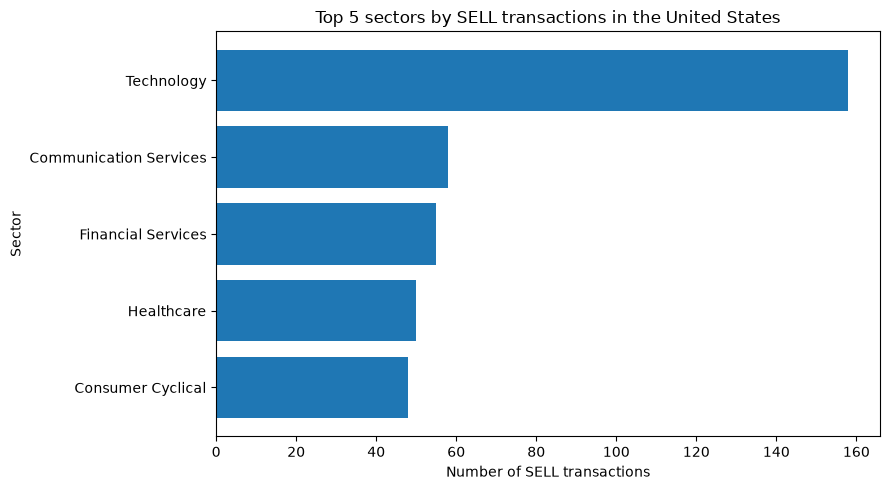

In [93]:
# Query 1
query1 = analysis_df[
    (analysis_df["transaction_type"] == "SELL") &
    (analysis_df["alpha_3"] == "USA")
]

query1_result = query1["sector"].value_counts().head(5).reset_index()
query1_result.columns = ["sector", "sell_transaction_count"]

query1_result["rank"] = range(1, len(query1_result) + 1)
query1_result = query1_result[["rank", "sector", "sell_transaction_count"]]

display(query1_result)

# Plot
plot_data = query1_result.sort_values("sell_transaction_count")

plt.figure(figsize=(9, 5))
plt.barh(plot_data["sector"], plot_data["sell_transaction_count"])
plt.title("Top 5 sectors by SELL transactions in the United States")
plt.xlabel("Number of SELL transactions")
plt.ylabel("Sector")
plt.tight_layout()
plt.show()

#### Query 2 - Top 5 industries by number of BUY transactions in Q4 2024




,rank,industry,buy_transaction_count
0,1,Semiconductors,18
1,2,Internet Content & Information,15
2,3,Software - Infrastructure,10
3,4,Internet Retail,8
4,5,Diagnostics & Research,7


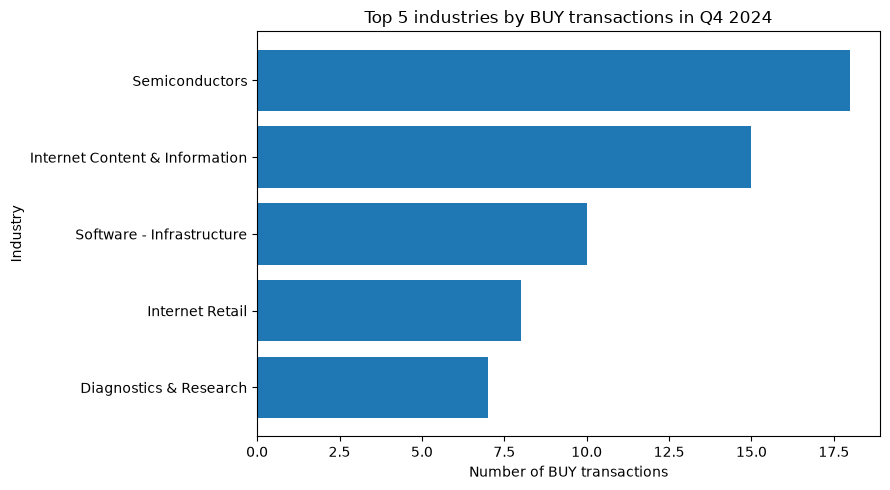

In [94]:
# Query 2
query2 = analysis_df[
    (analysis_df["year"] == 2024) &
    (analysis_df["quarter"] == "Q4") &
    (analysis_df["transaction_type"] == "BUY")
]

query2_result = query2["industry"].value_counts().head(5).reset_index()
query2_result.columns = ["industry", "buy_transaction_count"]

query2_result["rank"] = range(1, len(query2_result) + 1)
query2_result = query2_result[["rank", "industry", "buy_transaction_count"]]

display(query2_result)

# Plot
plot_data = query2_result.sort_values("buy_transaction_count")

plt.figure(figsize=(9, 5))
plt.barh(plot_data["industry"], plot_data["buy_transaction_count"])
plt.title("Top 5 industries by BUY transactions in Q4 2024")
plt.xlabel("Number of BUY transactions")
plt.ylabel("Industry")
plt.tight_layout()
plt.show()

#### Query 3 - Rank all quarters of 2024 by total number of BUY + SELL transactions


,rank,quarter,transaction_count
0,1,Q1,968
1,2,Q2,522
2,3,Q3,242
3,4,Q4,241


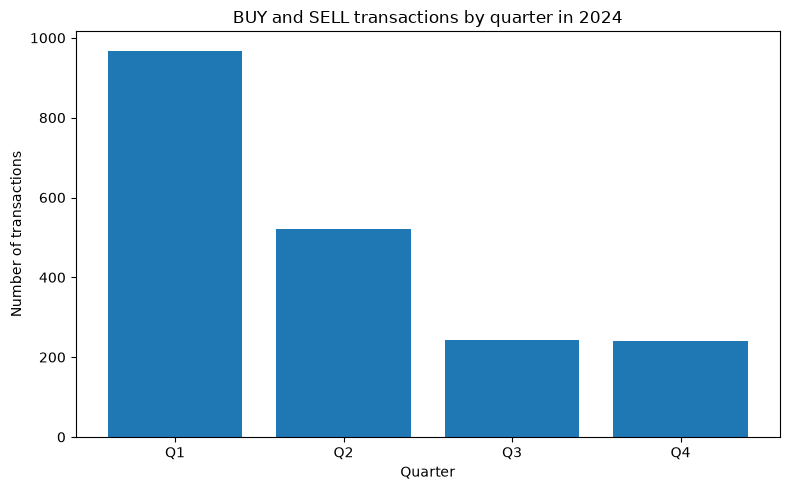

In [95]:
# Query 3
query3 = analysis_df[
    (analysis_df["year"] == 2024) &
    (analysis_df["transaction_type"].isin(["BUY", "SELL"]))
]

query3_result = query3["quarter"].value_counts().reset_index()
query3_result.columns = ["quarter", "transaction_count"]

query3_result["rank"] = range(1, len(query3_result) + 1)
query3_result = query3_result[["rank", "quarter", "transaction_count"]]

display(query3_result)

# Plot
quarter_order = {"Q1": 1, "Q2": 2, "Q3": 3, "Q4": 4}

plot_data = query3_result.copy()
plot_data["quarter_order"] = plot_data["quarter"].map(quarter_order)
plot_data = plot_data.sort_values("quarter_order")

plt.figure(figsize=(8, 5))
plt.bar(plot_data["quarter"], plot_data["transaction_count"])
plt.title("BUY and SELL transactions by quarter in 2024")
plt.xlabel("Quarter")
plt.ylabel("Number of transactions")
plt.tight_layout()
plt.show()

Most BUY and SELL transactions are concentrated in Q1, while the number of transactions decreases in the following quarters.

#### Query 4 - Top 10 countries by number of SELL transactions in 2024




,rank,country,sell_transaction_count
0,1,United States of America,389
1,2,United Kingdom of Great Britain and Northern I...,130
2,3,China,112
3,4,Brazil,69
4,5,"Taiwan, Province of China",50
5,6,"Netherlands, Kingdom of the",46
6,7,Switzerland,37
7,8,Ireland,31
8,9,Luxembourg,27
9,10,Canada,22


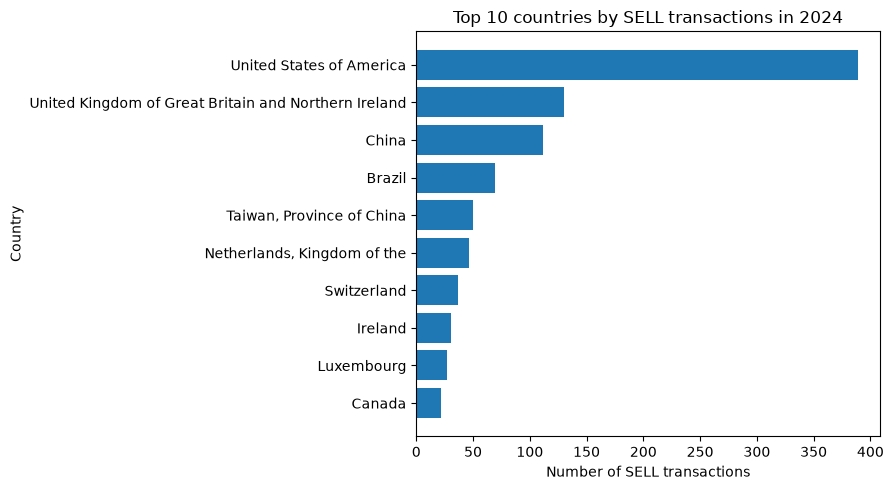

In [96]:
# Query 4
query4 = analysis_df[
    (analysis_df["year"] == 2024) &
    (analysis_df["transaction_type"] == "SELL")
]

query4_result = query4["country"].value_counts().head(10).reset_index()
query4_result.columns = ["country", "sell_transaction_count"]

query4_result["rank"] = range(1, len(query4_result) + 1)
query4_result = query4_result[["rank", "country", "sell_transaction_count"]]

display(query4_result)

# Plot
plot_data = query4_result.sort_values("sell_transaction_count")

plt.figure(figsize=(9, 5))
plt.barh(plot_data["country"], plot_data["sell_transaction_count"])
plt.title("Top 10 countries by SELL transactions in 2024")
plt.xlabel("Number of SELL transactions")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

#### Query 5 - Top 5 regions by total units bought in 2024



,rank,region,total_units_bought
0,1,Americas,37026
2,2,Europe,22528
1,3,Asia,9198


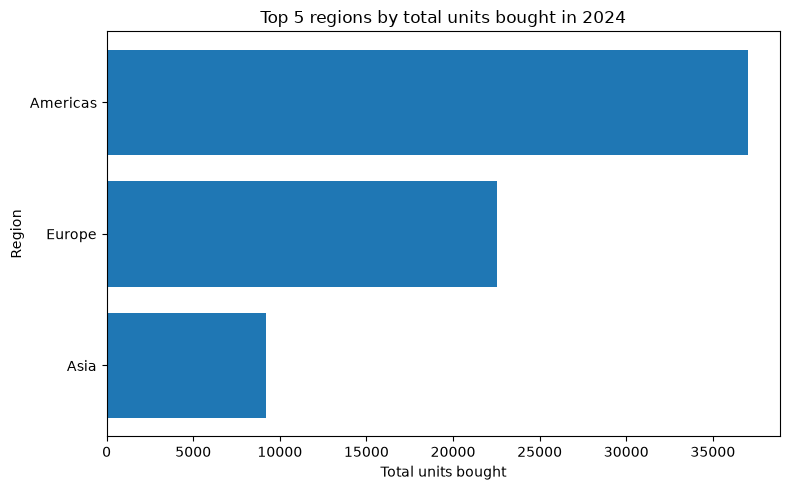

In [97]:
# Query 5
query5 = analysis_df[
    (analysis_df["year"] == 2024) &
    (analysis_df["transaction_type"] == "BUY")
]

query5_result = query5.groupby("region")["unit"].sum().reset_index()
query5_result = query5_result.sort_values("unit", ascending=False).head(5)

query5_result.columns = ["region", "total_units_bought"]

query5_result["rank"] = range(1, len(query5_result) + 1)
query5_result = query5_result[["rank", "region", "total_units_bought"]]

display(query5_result)

# Plot
plot_data = query5_result.sort_values("total_units_bought")

plt.figure(figsize=(8, 5))
plt.barh(plot_data["region"], plot_data["total_units_bought"])
plt.title("Top 5 regions by total units bought in 2024")
plt.xlabel("Total units bought")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

#### Query 6 - Top 5 sectors by total units traded in Q3 2024



,rank,sector,total_units_traded
8,1,Technology,4461
6,2,Healthcare,3572
2,3,Consumer Cyclical,2667
5,4,Financial Services,2054
1,5,Communication Services,1863


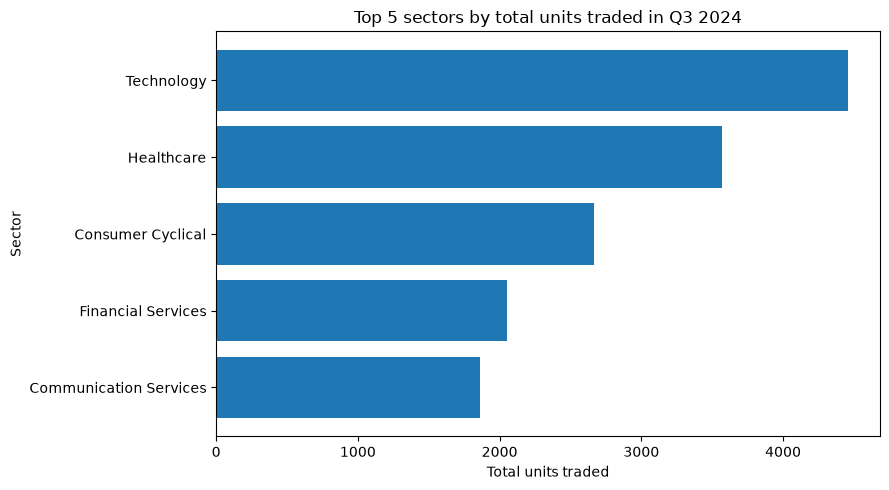

In [98]:
# Query 6
query6 = analysis_df[
    (analysis_df["year"] == 2024) &
    (analysis_df["quarter"] == "Q3") &
    (analysis_df["transaction_type"].isin(["BUY", "SELL"]))
]

query6_result = query6.groupby("sector")["unit"].sum().reset_index()
query6_result = query6_result.sort_values("unit", ascending=False).head(5)

query6_result.columns = ["sector", "total_units_traded"]

query6_result["rank"] = range(1, len(query6_result) + 1)
query6_result = query6_result[["rank", "sector", "total_units_traded"]]

display(query6_result)

# Plot
plot_data = query6_result.sort_values("total_units_traded")

plt.figure(figsize=(9, 5))
plt.barh(plot_data["sector"], plot_data["total_units_traded"])
plt.title("Top 5 sectors by total units traded in Q3 2024")
plt.xlabel("Total units traded")
plt.ylabel("Sector")
plt.tight_layout()
plt.show()


Here, traded units include both BUY and SELL transactions, so the result measures volume rather than number of transactions.

#### Query 11 - Top 5 sub-regions by number of transactions in Q4 2024




,rank,sub_region,transaction_count
0,1,Northern America,130
1,2,Northern Europe,37
2,3,Eastern Asia,28
3,4,Western Europe,24
4,5,Latin America and the Caribbean,23


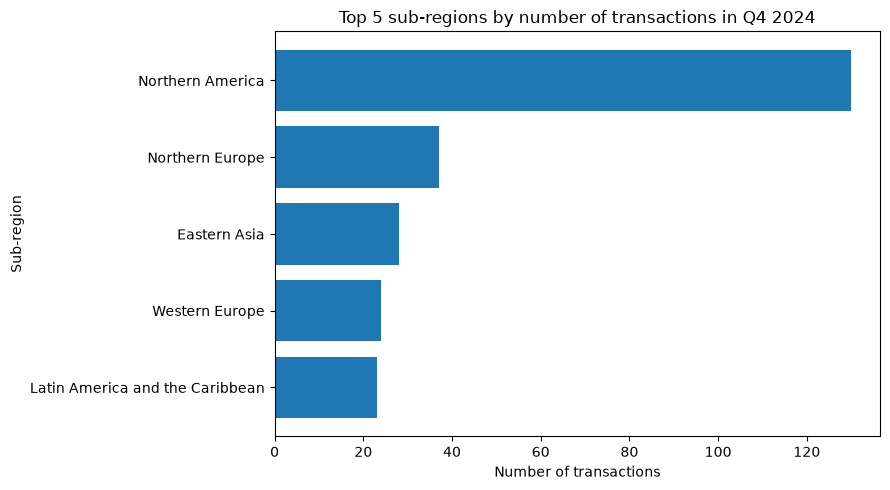

In [99]:
# Query 11
query11 = analysis_df[
    (analysis_df["year"] == 2024) &
    (analysis_df["quarter"] == "Q4")
]

query11_result = query11["sub_region"].value_counts().head(5).reset_index()
query11_result.columns = ["sub_region", "transaction_count"]

query11_result["rank"] = range(1, len(query11_result) + 1)
query11_result = query11_result[["rank", "sub_region", "transaction_count"]]

display(query11_result)

# Plot
plot_data = query11_result.sort_values("transaction_count")

plt.figure(figsize=(9, 5))
plt.barh(plot_data["sub_region"], plot_data["transaction_count"])
plt.title("Top 5 sub-regions by number of transactions in Q4 2024")
plt.xlabel("Number of transactions")
plt.ylabel("Sub-region")
plt.tight_layout()
plt.show()

#### Query 14 - Top 10 industry-region pairs by total number of transactions in 2024



,rank,industry,region,transaction_count
59,1,Semiconductors,Americas,134
64,2,Software - Infrastructure,Americas,132
38,3,Internet Content & Information,Americas,119
60,4,Semiconductors,Europe,100
70,5,Telecom Services,Americas,81
11,6,Biotechnology,Europe,66
61,7,Software - Application,Americas,61
7,8,Auto Manufacturers,Asia,60
10,9,Biotechnology,Americas,59
18,10,Credit Services,Americas,48


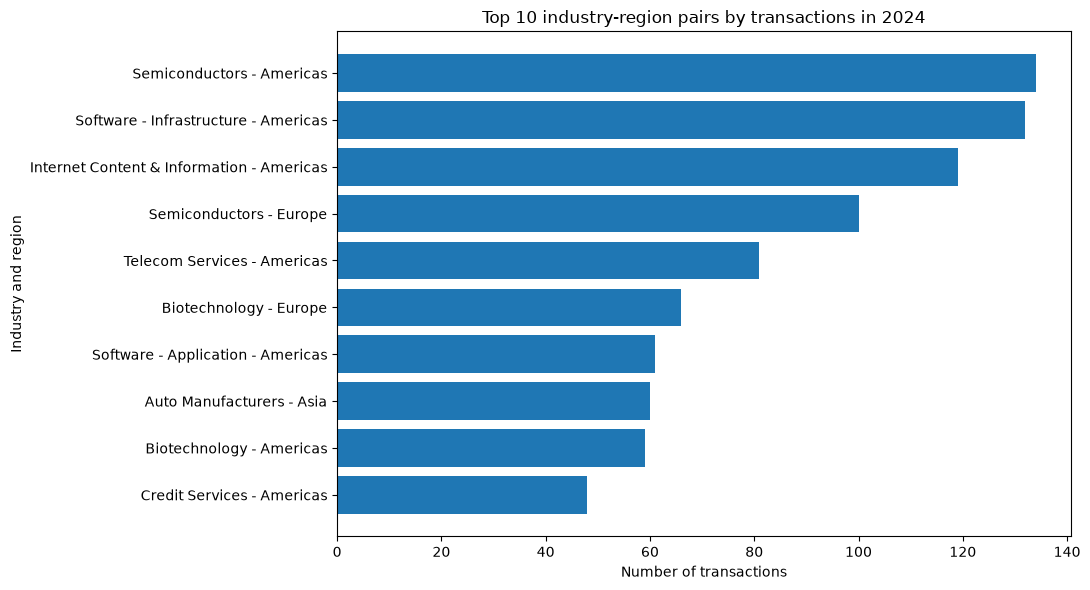

In [100]:
# Query 14
query14 = analysis_df[
    analysis_df["year"] == 2024
]

query14_result = query14.groupby(["industry", "region"]).size().reset_index()
query14_result.columns = ["industry", "region", "transaction_count"]

query14_result = query14_result.sort_values("transaction_count", ascending=False).head(10)

query14_result["rank"] = range(1, len(query14_result) + 1)
query14_result = query14_result[["rank", "industry", "region", "transaction_count"]]

display(query14_result)

# Plot
plot_data = query14_result.copy()
plot_data["industry_region"] = plot_data["industry"] + " - " + plot_data["region"]
plot_data = plot_data.sort_values("transaction_count")

plt.figure(figsize=(11, 6))
plt.barh(plot_data["industry_region"], plot_data["transaction_count"])
plt.title("Top 10 industry-region pairs by transactions in 2024")
plt.xlabel("Number of transactions")
plt.ylabel("Industry and region")
plt.tight_layout()
plt.show()

This query combines the business dimension and the geography dimension, showing which industry-region combinations appear most often in the transactions.